
# Predicción de Abandono Escolar

Proyecto de Machine Learning aplicado a educación y pobreza.

## Objetivo
Clasificar estudiantes en:
- `0 → Estudiante estable`
- `1 → Riesgo de abandono`

Utilizando variables socioeconómicas y académicas mediante Logistic Regression.



# Importación de Librerías


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score
)

print("Librerías cargadas correctamente.")


Librerías cargadas correctamente.



# Carga del Dataset

El archivo `estudiantes.csv` debe estar ubicado en:

```text
data/estudiantes.csv
```


In [2]:
# Carga del Dataset
from google.colab import drive
drive.mount('/content/drive')

import os # Added: Import the os module here

#Define the path to the 'data' folder within your mounted Google Drive
data_folder_path = '/content/drive/MyDrive/data'

# Comprueba si la carpeta existe
if os.path.exists(data_folder_path):
    print(f"La carpeta '{data_folder_path}' existe.")
    # Si existe, lista los contenidos para verificar archivo .csv
    print("Contenido de 'data':")
    for item in os.listdir(data_folder_path):
        print(f"- {item}")
    # Corrected: Use the full path for pd.read_csv
    df = pd.read_csv(os.path.join(data_folder_path, 'estudiantes.csv'))
    print("Dataset cargado correctamente.")
    print(df.head())
else:
    print(f"La carpeta '{data_folder_path}' NO existe.")
    print("Por favor, asegure que ha creado'data' en su Google Drive y cargo el archivo .csv.")
    # If the folder doesn't exist, we can't load the DataFrame, so handle it.
    df = None # Set df to None or handle the error appropriately


Mounted at /content/drive
La carpeta '/content/drive/MyDrive/data' existe.
Contenido de 'data':
- estudiantes.csv
Dataset cargado correctamente.
   distancia_escuela  acceso_internet  nivel_socioeconomico  promedio_notas  \
0               10.5                1                     2              67   
1                6.8                1                     2              62   
2                9.2                1                     1              41   
3                9.6                1                     2              71   
4                2.2                0                     3              75   

   asistencia  apoyo_familiar  trabaja  abandono  
0          76               0        1         0  
1          88               0        0         0  
2          64               0        0         1  
3          58               1        0         0  
4          70               1        0         0  



# Exploración Inicial de Datos


In [12]:
# Exploracion Inicial de Datos
print("Dimensiones del dataset:")
print(df.shape)

print("\nTipos de datos:")
df.info()


Dimensiones del dataset:
(1000, 8)

Tipos de datos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   distancia_escuela     1000 non-null   float64
 1   acceso_internet       1000 non-null   int64  
 2   nivel_socioeconomico  1000 non-null   int64  
 3   promedio_notas        1000 non-null   int64  
 4   asistencia            1000 non-null   int64  
 5   apoyo_familiar        1000 non-null   int64  
 6   trabaja               1000 non-null   int64  
 7   abandono              1000 non-null   int64  
dtypes: float64(1), int64(7)
memory usage: 62.6 KB


In [13]:
# Mostramos la descripción del Dataset
df.describe()


,distancia_escuela,acceso_internet,nivel_socioeconomico,promedio_notas,asistencia,apoyo_familiar,trabaja,abandono
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.00000,1000.00000,1000.00000
mean,8.106600,0.62200,1.803000,69.640000,79.169000,0.69400,0.24900,0.18300
std,4.851224,0.48513,0.762084,14.782385,13.437746,0.46106,0.43265,0.38686
min,0.500000,0.00000,1.000000,30.000000,40.000000,0.00000,0.00000,0.00000
25%,4.400000,0.00000,1.000000,59.750000,70.000000,0.00000,0.00000,0.00000
50%,8.000000,1.00000,2.000000,70.000000,80.000000,1.00000,0.00000,0.00000
75%,11.400000,1.00000,2.000000,80.000000,89.000000,1.00000,0.00000,0.00000
max,23.800000,1.00000,3.000000,100.000000,100.000000,1.00000,1.00000,1.00000



# Distribución de la Variable Objetivo


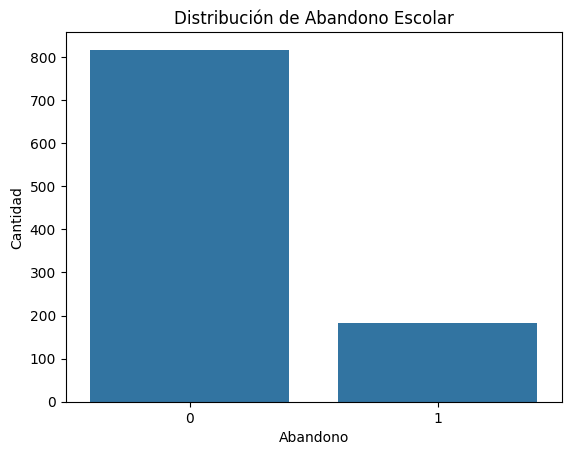

In [17]:
# Distribución de la Variable Objetivo
# Nota: La información está obtenida del dataset (inicialmente con 600 registros)
# abandono: es la variable objetivo para abandono_escolar
sns.countplot(x='abandono', data=df)

plt.title("Distribución de Abandono Escolar")
plt.xlabel("Abandono")
plt.ylabel("Cantidad")

plt.show()



# Preparación de Variables


In [18]:
# Preparación de las variables predictoras: "abandono" para abandono_escolar
X = df.drop('abandono', axis=1)
y = df['abandono']

print("Variables predictoras:")
print(X.columns)


Variables predictoras:
Index(['distancia_escuela', 'acceso_internet', 'nivel_socioeconomico',
       'promedio_notas', 'asistencia', 'apoyo_familiar', 'trabaja'],
      dtype='object')



# División Train/Test


In [19]:
# División de datos para Train/Test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Datos divididos correctamente.")


Datos divididos correctamente.



# Escalado de Variables


In [20]:
# Escalado básico de las variables
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Escalado completado.")


Escalado completado.



# Entrenamiento del Modelo

Modelo utilizado:

- Logistic Regression


In [21]:
# Entrenamiento del modelo, con clasificacion binaria, mediante: Logistic Regression
modelo = LogisticRegression()

modelo.fit(X_train, y_train)

print("Modelo entrenado correctamente.")


Modelo entrenado correctamente.



# Predicciones


In [22]:
# Predicciones
y_pred = modelo.predict(X_test)

print("Predicciones generadas.")


Predicciones generadas.



# Evaluación del Modelo


In [23]:
#Evaluación del modelo
y_pred = modelo.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy del modelo: {accuracy:.2f}")

Accuracy del modelo: 0.93


In [24]:
# Mostrar los resultados del modelo predict
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.95      0.96      0.95       162
           1       0.83      0.76      0.79        38

    accuracy                           0.93       200
   macro avg       0.89      0.86      0.87       200
weighted avg       0.92      0.93      0.92       200




# Matriz de Confusión


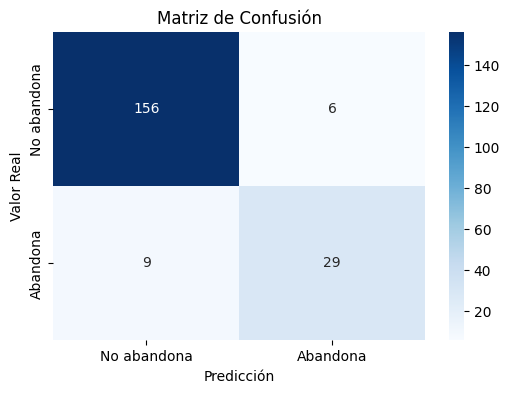

In [26]:
# Mostrar la matriz de confusion
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No abandona', 'Abandona'],
    yticklabels=['No abandona', 'Abandona']
)

plt.xlabel("Predicción")
plt.ylabel("Valor Real")
plt.title("Matriz de Confusión")

plt.show()



# Importancia de Variables


In [27]:
# Revisar la importancia de las Variables
coeficientes = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': modelo.coef_[0]
})

coeficientes = coeficientes.sort_values(
    by='Coeficiente',
    ascending=False
)

coeficientes


,Variable,Coeficiente
6,trabaja,1.165413
0,distancia_escuela,1.051848
3,promedio_notas,-0.817698
5,apoyo_familiar,-1.071431
2,nivel_socioeconomico,-1.178054
1,acceso_internet,-1.315676
4,asistencia,-2.012660



# Interpretación de Resultados

## Posibles Hallazgos

- Baja asistencia aumenta el riesgo de abandono.
- Bajo promedio académico influye negativamente.
- Falta de acceso a internet incrementa vulnerabilidad.
- Distancias largas a la escuela pueden afectar permanencia.

## Impacto Institucional

Este modelo puede ayudar a:

- Detectar estudiantes vulnerables.
- Priorizar apoyos escolares.
- Implementar intervenciones tempranas.
- Reducir la deserción escolar.



# Próximas Mejoras

## Técnicas
- Random Forest
- XGBoost
- Balanceo de clases
- Validación cruzada

## Funcionales
- Dashboard interactivo
- Predicción en tiempo real
- Sistema de alertas escolares
